## ElasticNet Regression

### Why Lasso wasn't enough?
Lasso is unstable when higjly correlated features exist.

### Why ElasticNet developed?
ElasticNet was developed to combine the strengths of Ridge and Lasso Regression. It performs regularization like Ridge while also supporting feature selection like Lasso. It also has aplha and also introduces l1_ratio. l1_ratio controls the balance between L1 (Lasso) and L2 (Ridge) regularization. A value closer to 1 behaves more like Lasso, while a value closer to 0 behaves more like Ridge.

In [1]:
# All imports same as in LR except model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import ElasticNet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import joblib

# Load dataset
df = pd.read_csv("../data/housing.csv")
# Remove address - RR also expects numerical input
df = df.drop("Address", axis=1)

X = df.drop("Price", axis=1)
y = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

elastic_model = ElasticNet(
    alpha=1.0,
    l1_ratio=0.5,
    random_state=42
)

elastic_model.fit(X_train, y_train)
y_pred = elastic_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)

MAE : 100124.30560571468
RMSE: 124745.7067229915
R² : 0.8735171828446279


In [2]:
joblib.dump(elastic_model, "../models/elastic_model.joblib")

['../models/elastic_model.joblib']

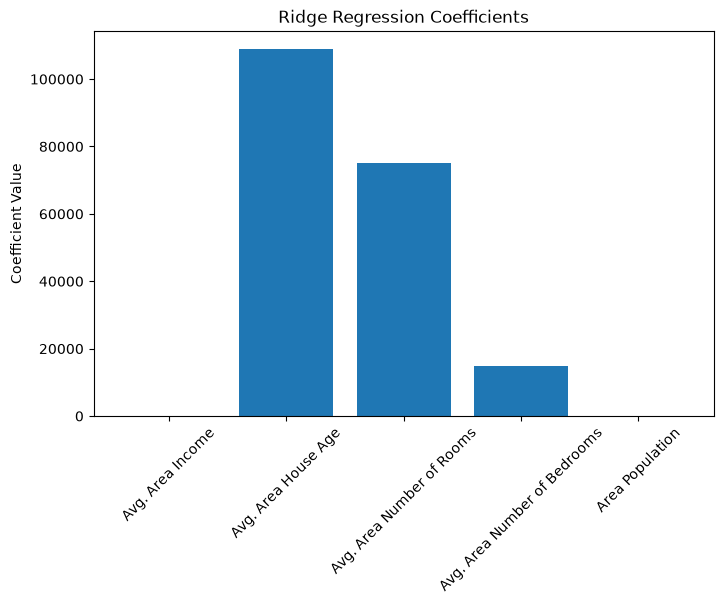

In [3]:
feature_names = X.columns
plt.figure(figsize=(8,5))

plt.bar(feature_names, elastic_model.coef_)

plt.xticks(rotation=45)
plt.title("Ridge Regression Coefficients")
plt.ylabel("Coefficient Value")
plt.show()

In [4]:
# Inspecting coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": elastic_model.coef_
})

coefficients

,Feature,Coefficient
0,Avg. Area Income,21.565266
1,Avg. Area House Age,108813.668307
2,Avg. Area Number of Rooms,75023.875021
3,Avg. Area Number of Bedrooms,14838.048531
4,Area Population,15.181982


### Why ElasticNet perform worse than Lasso?
The Housing dataset contains only a few meaningful numerical features and does not exhibit severe multicollinearity or many irrelevant features. ElasticNet introduces additional regularization, which reduced the model's flexibility. With the chosen hyperparameters (alpha=1.0, l1_ratio=0.5), this led to underfitting and lower predictive performance compared to Linear Regression.

In [5]:
for alpha in [0.01, 0.1, 1, 10]:
    model = ElasticNet(alpha=alpha, l1_ratio=0.5, random_state=42)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    print("Alpha:", alpha)
    print("R²:", r2_score(y_test, pred))
    print()

Alpha: 0.01
R²: 0.9178741170818132

Alpha: 0.1
R²: 0.9160882634537799

Alpha: 1
R²: 0.8735171828446279

Alpha: 10
R²: 0.6770518994392647



Here when alpha is 0.01 it is 0.918

Machine Learning is about Choosing the right algorithm for the right dataset.  
On this dataset:  
**🥇 Linear Regression is still the best so far.**